In [1]:
# set cwd
import sys
import os
# Tweak to ensure cwd is at root of repo
os.chdir('..')
print(os.getcwd())

C:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\CST-Part-II-Project-Code


In [2]:
from typing import (
    Sequence,
    List,
    Tuple,
    Optional,
    Set,
    Dict,
)
from src.utils.qccd_nodes import *
from src.utils.qccd_operations import *
from src.utils.qccd_operations_on_qubits import *
from src.utils.qccd_arch import *
from src.compiler.qccd_parallelisation import *
from src.compiler.qccd_qubits_to_ions import *
from src.compiler.qccd_ion_routing import *
from src.compiler.qccd_alt_ion_routing import *
from src.compiler.qccd_WISE_ion_route import *
from src.compiler.qccd_color_qubits_to_ions import *

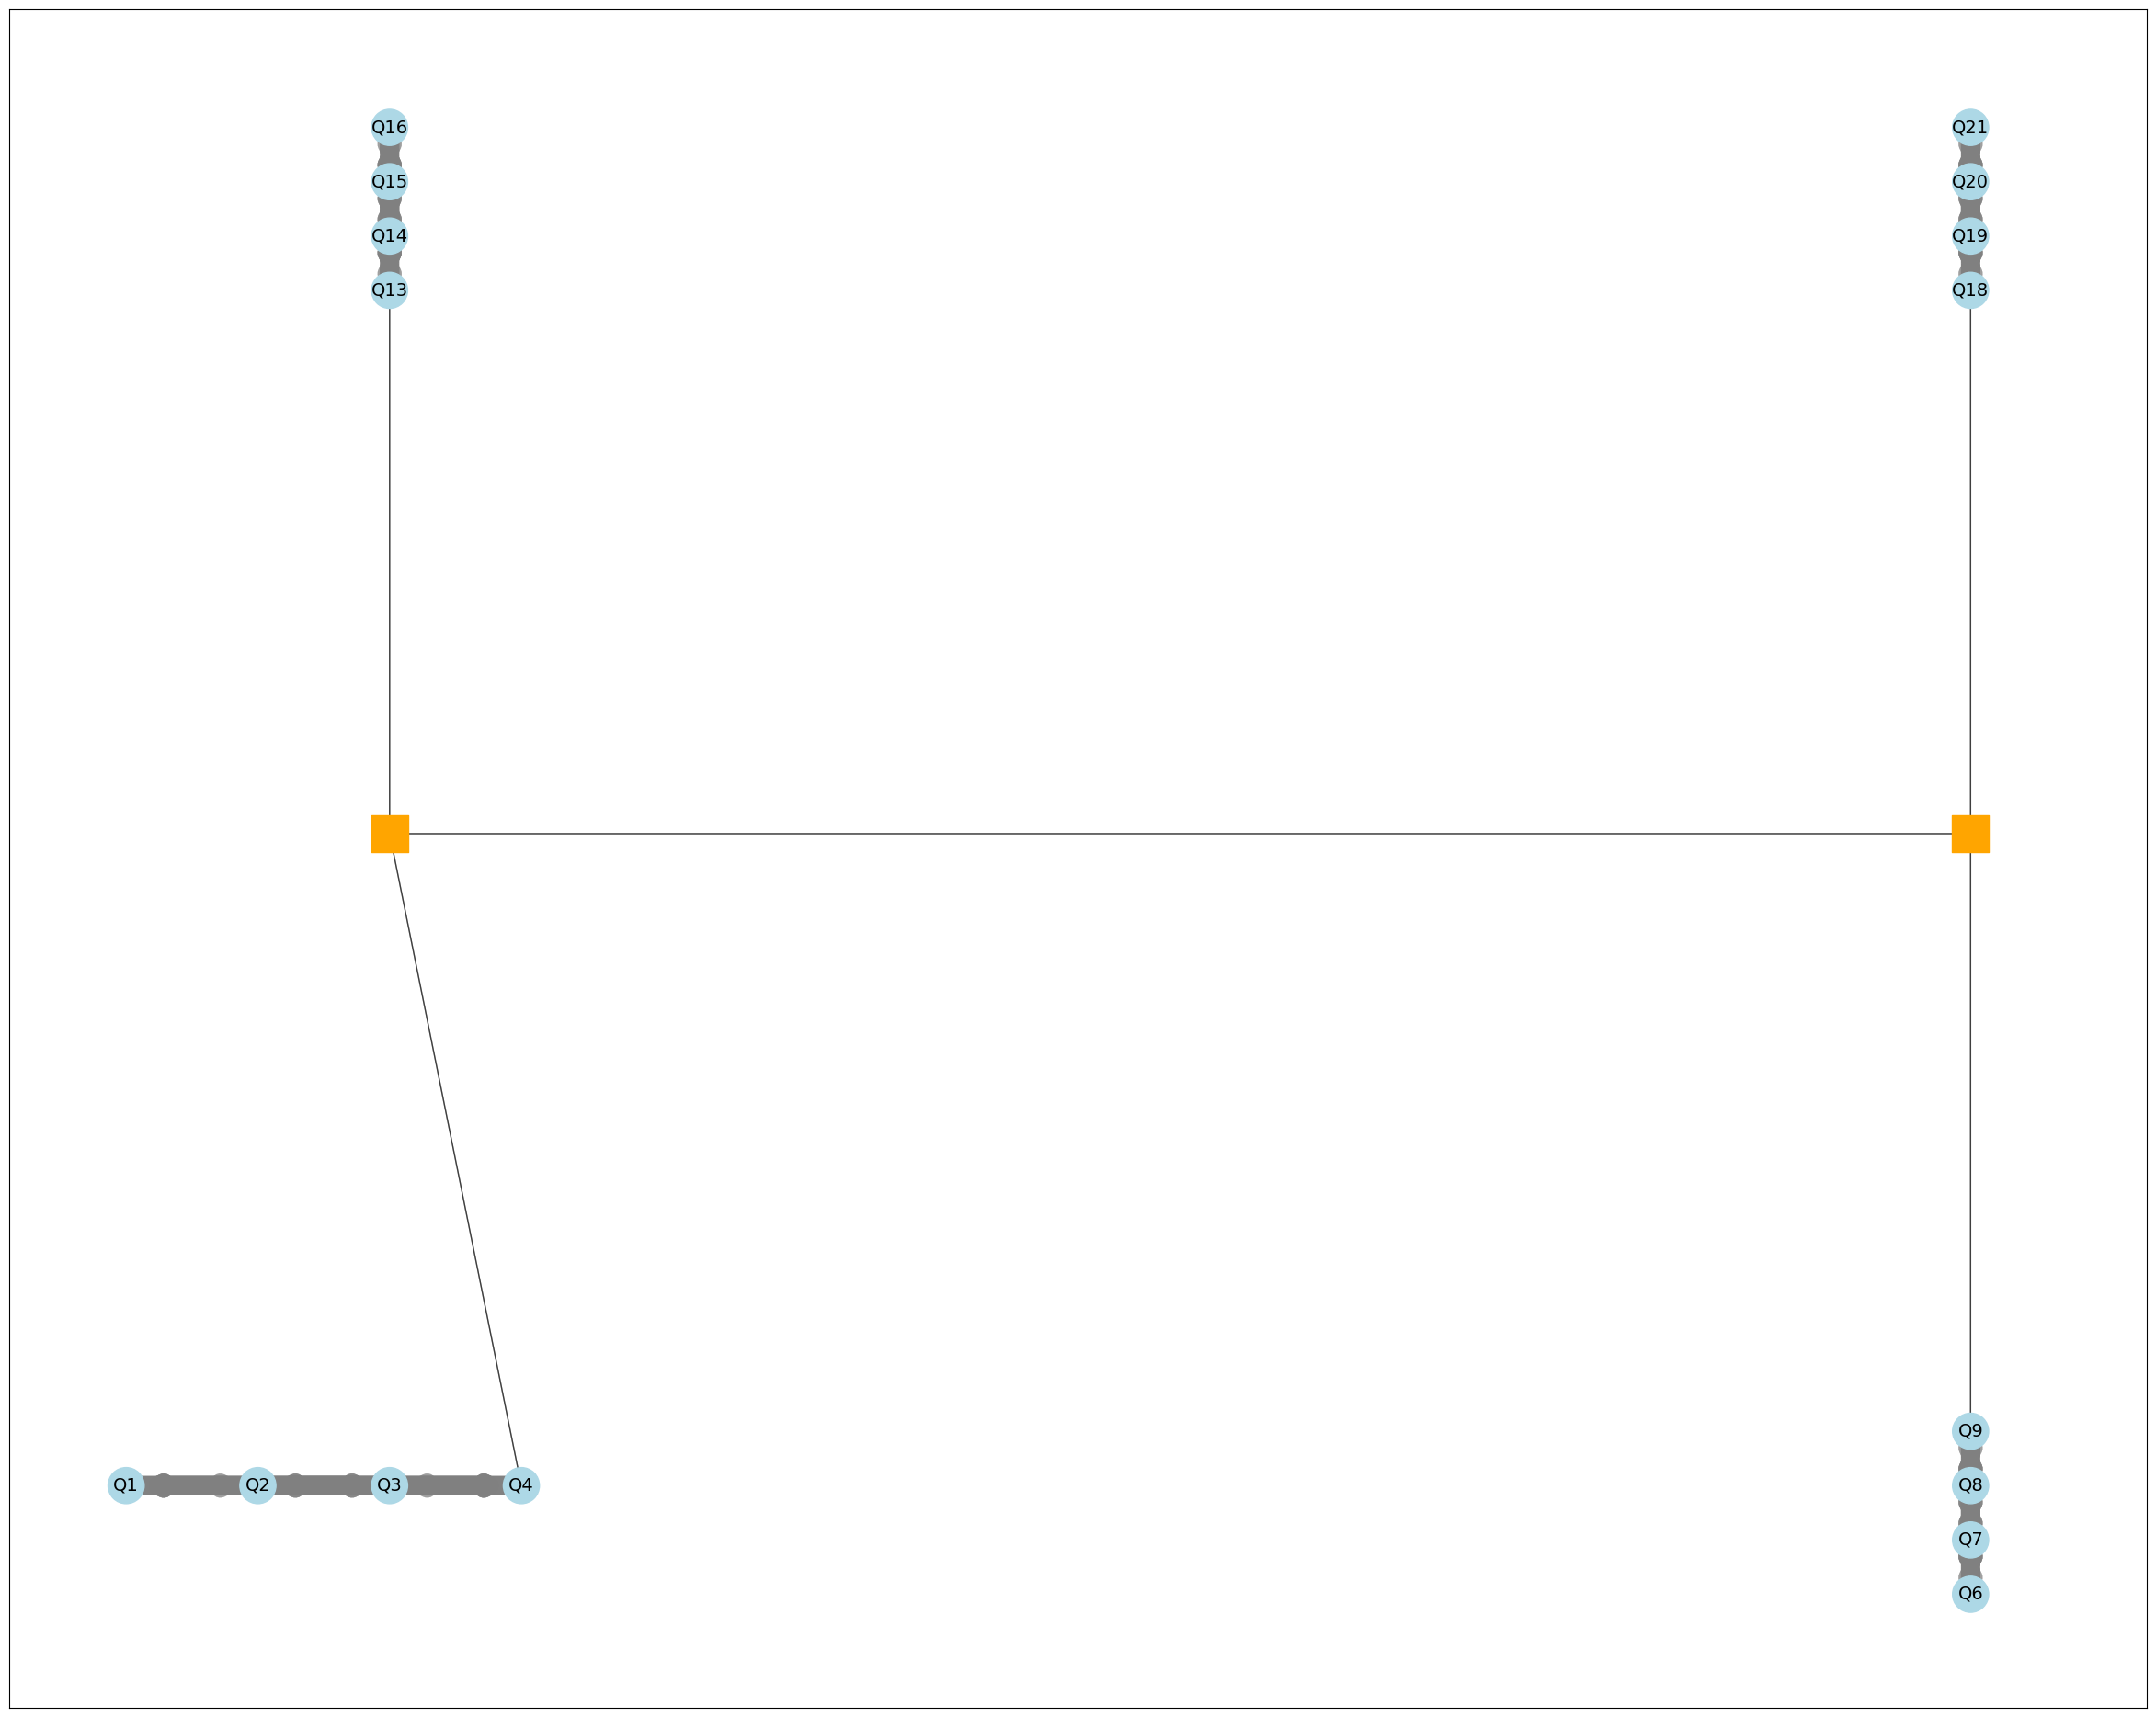

In [4]:
#testing creation of a triangular grid
"""
def processColorCircuitTriangularGrid(
    self,
    trapCapacity:int = 2,
    height:int = 1,
    width:int = 5,
    padding:int = 1,
    dataQubitIdxs:Optional[Sequence[int]]=None):

    instructions, barriers = self._parseCircuitString(dataQubitsIdxs=dataQubitsIdxs)"""

arch = QCCDArch()

ionspacing = 1
trapspacing = 6
qubit_colour = 'red'
qubit_colour = 'lightblue'
junction_colour = 'orange'
traps = []

ManipulationTrap.DEFAULT_SPACING = trapspacing
arch.SIZING = 0.5
ions11 = [QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q'), QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q')]
trap11 = arch.addManipulationTrap(x=0, y=0, ions=ions11, color='grey', spacing=ionspacing, isHorizontal=True)

ions12 = [QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q'), QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q')]
trap12 = arch.addManipulationTrap(x=trapspacing, y=0, ions=ions12, color='grey', spacing=ionspacing, isHorizontal=False)

junctionL = arch.addJunction(x=0, y=trapspacing, color=junction_colour)
junctionR = arch.addJunction(x=trapspacing, y=trapspacing, color=junction_colour)

ions21 = [QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q'), QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q')]
trap21 = arch.addManipulationTrap(x=0, y=2*trapspacing, ions=ions21, color='grey', spacing=ionspacing, isHorizontal=False)

ions22 = [QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q'), QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q')]
trap22 = arch.addManipulationTrap(x=trapspacing, y=2*trapspacing, ions=ions22, color='grey', spacing=ionspacing, isHorizontal=False)

crossing11 = arch.addEdge(trap11, junctionL)
arch.addEdge(trap12, junctionR)
crossing21 = arch.addEdge(trap21, junctionL)
arch.addEdge(trap22, junctionR)
arch.addEdge(junctionL, junctionR)

arch.refreshGraph()
# Display architecture
fig, ax = plt.subplots()
# Display architecture
arch.display(fig,ax, showLabels=False)

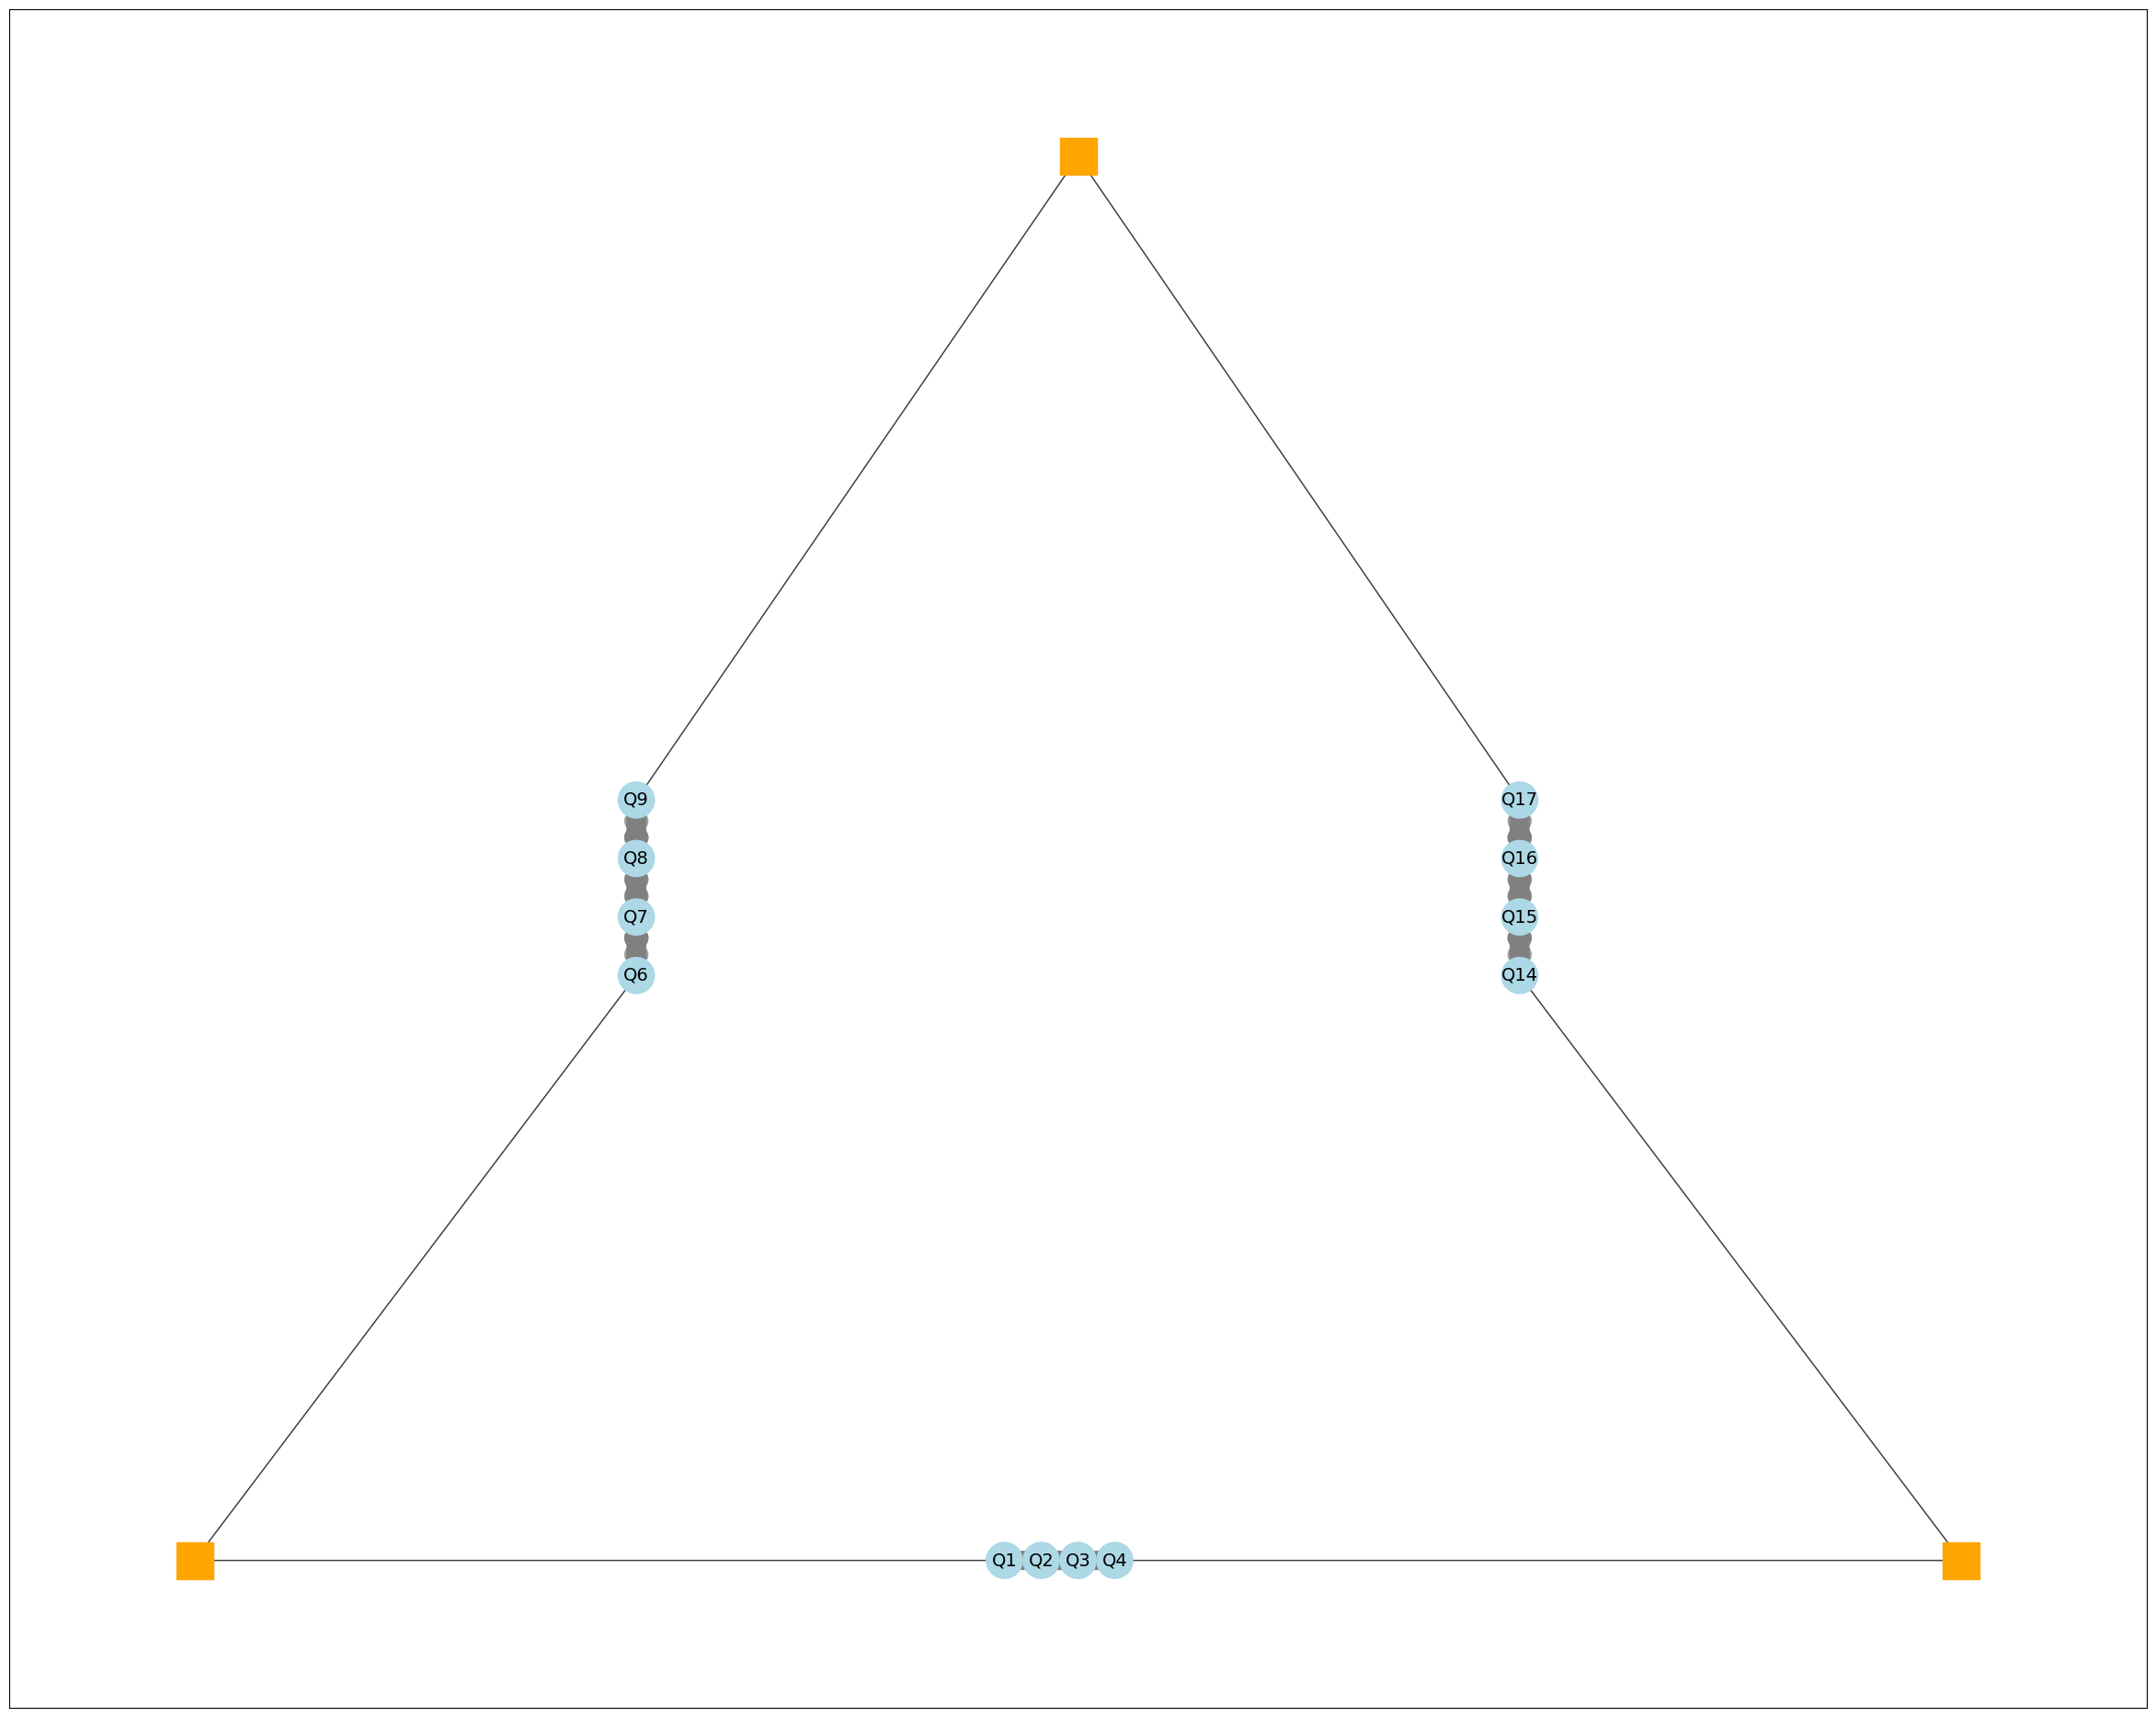

In [6]:
arch = QCCDArch()

ionspacing = 1
trapspacing = 6
qubit_colour = 'red'
qubit_colour = 'lightblue'
junction_colour = 'orange'
traps = []

ManipulationTrap.DEFAULT_SPACING = trapspacing
arch.SIZING = 0.5
ions11 = [QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q'), QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q')]
trap11 = arch.addManipulationTrap(x=2*trapspacing, y=0, ions=ions11, color='grey', spacing=ionspacing, isHorizontal=True)

ions12 = [QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q'), QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q')]
trap12 = arch.addManipulationTrap(x=trapspacing, y=trapspacing, ions=ions12, color='grey', spacing=ionspacing, isHorizontal=False)

junctionL = arch.addJunction(x=0, y=0, color=junction_colour)
junctionR = arch.addJunction(x=4*trapspacing, y=0, color=junction_colour)
junctionM = arch.addJunction(x=2*trapspacing, y=2*trapspacing, color=junction_colour)

ions21 = [QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q'), QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q')]
trap21 = arch.addManipulationTrap(x=3*trapspacing, y=trapspacing, ions=ions21, color='grey', spacing=ionspacing, isHorizontal=False)



arch.addEdge(trap11, junctionL)
arch.addEdge(trap11, junctionR)
arch.addEdge(trap12, junctionL)
arch.addEdge(trap12, junctionM)
arch.addEdge(trap21, junctionR)
arch.addEdge(trap21, junctionM)

arch.refreshGraph()
# Display architecture
fig, ax = plt.subplots()
# Display architecture
arch.display(fig,ax, showLabels=False)

In [14]:
from src.color_code_utils.color_code_circuits.color_code_circuit_666 import *
from src.compiler.qccd_qubits_to_ions import * 

cc = ColorCodeCircuit666(3,3)

print(cc.qtoid)
ids = []
coords = []
nonpcoords = []
for coord,i in cc.qtoid.items():
    ids.append(i)
    coords.append(np.array(coord))
    nonpcoords.append((coord))
#print(ids)
#print(coords)

gridpos = [(2,0), (1,1), (3,1)]

parts = TriangularPartitionIons(ids, np.array(coords),10)
print(f'clusters: {parts}')
arrangeClusters(parts, gridpos)

{(0, 0): 0, (1, 1): 1, (2, 0): 2, (2, 2): 3, (3, 1): 4, (3, 3): 5, (4, 0): 6, (4, 2): 7, (5, 1): 8, (6, 0): 9}
clusters: [([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], (np.float64(3.0), np.float64(1.0)))]


[array([3, 1])]

In [ ]:
padding = 1

allGridPos = []
for y in range(width):
    offset = 2*h*padding
    for x in range(width):
        allGridPos.append(